# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y=y_train
y2=y_test
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


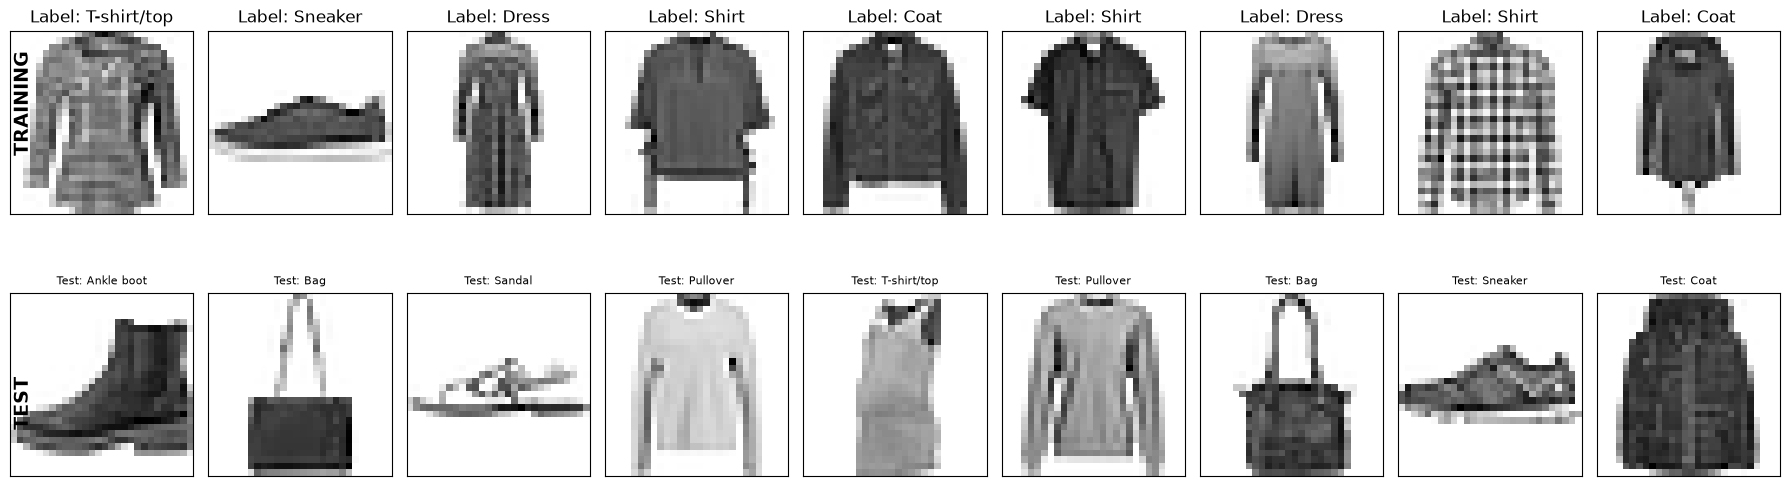

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

random_indices = np.random.choice(len(X_test), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(2, 9, figsize=(18, 6))  # 2 rows, 9 columns
for i, ax in enumerate(axes[0]):
    ax.imshow(X_train[random_indices[i]],   cmap=plt.cm.gray_r,interpolation='nearest')
    ax.set_title(f"Label: {class_names[y[random_indices[i]]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

for i, ax in enumerate(axes[1]):
    ax.imshow(X_test[random_indices[i]],  cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Test: {class_names[y2[random_indices[i]]]}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

fig.text(0.01, 0.75, 'TRAINING', fontsize=14, fontweight='bold', rotation=90, va='center')
fig.text(0.01, 0.25, 'TEST', fontsize=14, fontweight='bold', rotation=90, va='center')

plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The images are only 28x28 pixels, so they are quite small and we cannot see many details. Also, clothing items in the same category can look very different from each other. For example, shirts can have short sleeves or long sleeves, and they can be tight or loose. This variety makes the classification task harder. I think this dataset will be more difficult to work with than the handwritten digits dataset, where each number looks more similar to others of the same type. 

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam

# Create  a non-linear softmax regression #keeping as assignment-1 uses this output. 
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28, 28, 1)))
model.add(Flatten())  # Flatten the input
model.add(Dense(56, activation='relu'))
model.add(Dense(10, activation='softmax')) # Dense layer with 10 units

# Compile the model using `model.compile()`
model.compile(optimizer= Adam(), # Stochastic Gradient Descent 
              loss= 'categorical_crossentropy', # For classification tasks
              metrics=['accuracy']
)
# Train the model with `model.fit()`
model.fit(X_train, 
          y_train, 
          epochs=10, 
          batch_size=32,
          validation_split=0.2
)
# Evaluate the model with `model.evaluate()`
test_loss,test_accuracy= model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8117 - loss: 0.5461 - val_accuracy: 0.8505 - val_loss: 0.4308
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8543 - loss: 0.4091 - val_accuracy: 0.8607 - val_loss: 0.3934
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8660 - loss: 0.3702 - val_accuracy: 0.8683 - val_loss: 0.3727
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8739 - loss: 0.3461 - val_accuracy: 0.8708 - val_loss: 0.3695
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8803 - loss: 0.3258 - val_accuracy: 0.8698 - val_loss: 0.3558
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8850 - loss: 0.3131 - val_accuracy: 0.8794 - val_loss: 0.3334
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8916 - loss: 0.2978 - val_accuracy: 0.8724 - val_loss: 0.3544
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8950 - loss: 0.2871 

In [9]:

# Create a simple linear regression model #Adding to meet requirements and to compare with  assignment 2
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28, 28, 1)))
model.add(Flatten())  # Flatten the input
model.add(Dense(56, activation='relu'))
model.add(Dense(10)) # Dense layer with 10 units

# Compile the model using `model.compile()`
model.compile(optimizer= Adam(), # Stochastic Gradient Descent 
              loss= 'categorical_crossentropy', # For classification tasks
              metrics=['accuracy']
)
# Train the model with `model.fit()`
model.fit(X_train, 
          y_train, 
          epochs=10, 
          batch_size=32,
          validation_split=0.2
)
# Evaluate the model with `model.evaluate()`
test_loss,test_accuracy= model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1074 - loss: 9.6171 - val_accuracy: 0.1026 - val_loss: 10.0134
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1029 - loss: 9.9811 - val_accuracy: 0.1085 - val_loss: 9.5957
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1071 - loss: 9.5718 - val_accuracy: 0.1085 - val_loss: 9.5916
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1071 - loss: 9.5718 - val_accuracy: 0.1085 - val_loss: 9.5916
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1071 - loss: 9.5718 - val_accuracy: 0.1085 - val_loss: 9.5916
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1071 - loss: 9.5718 - val_accuracy: 0.1085 - val_loss: 9.5916
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1071 - loss: 9.5718 - val_accuracy: 0.1085 - val_loss: 9.5916
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.1071 - loss: 9.5718 

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The simple linear regression model performs poorly, as it achieves about 10%  accuracy on training data and on test data.This poor performance is because a single linear layer is't specifically designed to recognize patterns in images (complex patters). 

Baseline in this assignmnet- The model non-linear softmax regression achieves about 90% accuracy on training data and 87% on test data. This is a decent result.
This performance is expected because the model is quite basic. It has just one hidden layer with 56 neurons and doesn't use convolutional layers, which are specifically designed to recognize patterns in images. As a result, the model can learn simple patterns from the pixels, but it struggles with more complex features like shapes, edges, or textures. I think that's why the val_accuracy stops improving at around 87% and doesn't get any higher.
If we wanted better results, we would need to design a more complex model with additional layers or use convolutional neural networks.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [11]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Input(shape=(28, 28, 1)))  # Add Input layer first
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Helps prevent overfitting
model.add(Dense(10, activation='softmax'))  # 10 classes 
# Compile the model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Train the model
model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)
# Evaluate the model
model.evaluate(X_test, y_test)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.7811 - loss: 0.6070 - val_accuracy: 0.8560 - val_loss: 0.3956
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.8558 - loss: 0.4020 - val_accuracy: 0.8808 - val_loss: 0.3193
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.8732 - loss: 0.3489 - val_accuracy: 0.8892 - val_loss: 0.2982
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.8850 - loss: 0.3174 - val_accuracy: 0.8963 - val_loss: 0.2830
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8954 - loss: 0.2882 - val_accuracy: 0.9015 - val_loss: 0.2611
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9028 - loss: 0.2706 - val_accuracy: 0.9040 - val_loss: 0.2579
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9075 - loss: 0.2541 - val_accuracy: 0.9068 - val_loss: 0.2496
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9128 -

[0.2551794946193695, 0.904699981212616]

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Yes, the CNN performed better than the baseline model. The baseline achieved about 86.3% test accuracy, while the CNN reached around 90.0%, an improvement.
This improvement happened because the CNN uses convolutional layers to detect local patterns like edges and shapes, rather than treating each pixel separately. The pooling layers also help by keeping only the most important information, while dropout prevents overfitting. Overall, the CNN is simply better suited for image data because it understands spatial relationships, which the baseline model completely ignored.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [12]:
# A. Test Hyperparameters

#Filters
import time
filter_configs = [
    {'name': 'Small (16,32)', 'filters': [16, 32]},
    {'name': 'Medium (32,64)', 'filters': [32, 64]},  # Original
    {'name': 'Large (64,128)', 'filters': [64, 128]}
]

# Store results
results_filters = []

for config in filter_configs:
    print(f"\nTesting filters: {config['name']}")
    
    # Re-initialize the model 
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(config['filters'][0], (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(config['filters'][1], (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    
    # Compile
    model.compile(optimizer=Adam(),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Train
    start_time = time.time()
    history = model.fit(X_train, y_train,
                         epochs=10, batch_size=32, validation_split=0.2, verbose=0) # Silent for cleaner output
    training_time = time.time() - start_time
    
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    # Store results
    results_filters.append({
        'config': config['name'],
        'filters_conv1': config['filters'][0],
        'filters_conv2': config['filters'][1],
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'val_accuracy': history.history['val_accuracy'][-1],
        'training_time': training_time,
        'history': history
    })

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Training Time: {training_time:.2f}s")


Testing filters: Small (16,32)
  Test Accuracy: 0.8960
  Validation Accuracy: 0.9026
  Training Time: 197.24s

Testing filters: Medium (32,64)
  Test Accuracy: 0.9037
  Validation Accuracy: 0.9128
  Training Time: 295.78s

Testing filters: Large (64,128)
  Test Accuracy: 0.9071
  Validation Accuracy: 0.9152
  Training Time: 554.33s


In [13]:
best_filter = max(results_filters, key=lambda x: x['test_accuracy'])
print(f"   Best performing: {best_filter['config']}")
print(f"   Test Accuracy: {best_filter['test_accuracy']:.4f}")
print(f"   Training Time: {best_filter['training_time']:.2f}s")

   Best performing: Large (64,128)
   Test Accuracy: 0.9071
   Training Time: 554.33s


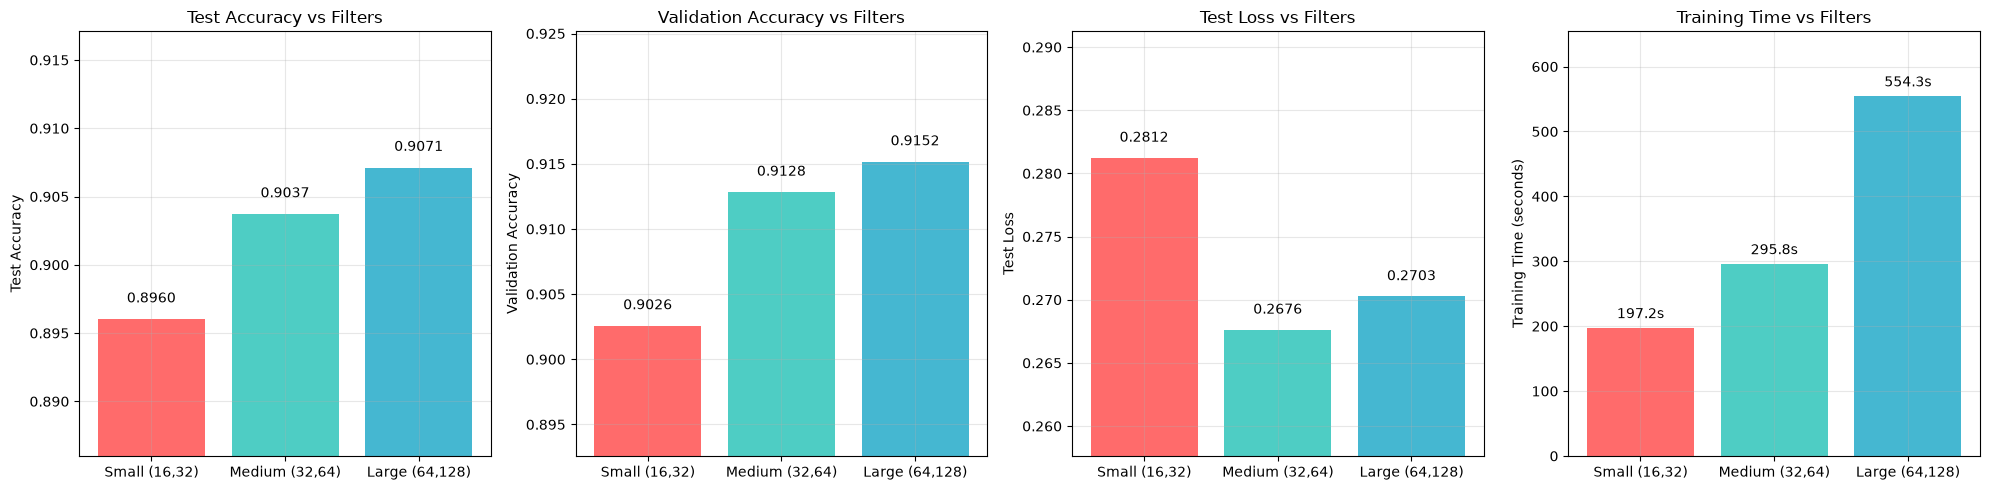

In [14]:
# Plots 
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

config_names = [r['config'] for r in results_filters]

# Filters vs Test Accuracy
ax = axes[0]
test_accs = [r['test_accuracy'] for r in results_filters]
bars = ax.bar(config_names, test_accs, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Test Accuracy vs Filters')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(min(test_accs) - 0.01, max(test_accs) + 0.01)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom')

# Filters vs Validation Accuracy
ax = axes[1]
val_accs = [r['val_accuracy'] for r in results_filters]
bars = ax.bar(config_names, val_accs, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Validation Accuracy vs Filters')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(min(val_accs) - 0.01, max(val_accs) + 0.01)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom')

#Filters vs Test Loss
ax = axes[2]
test_losses = [r['test_loss'] for r in results_filters]
bars = ax.bar(config_names, test_losses, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Test Loss vs Filters')
ax.set_ylabel('Test Loss')
ax.set_ylim(min(test_losses) - 0.01, max(test_losses) + 0.01)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, test_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom')

#Filters vs Training Time
ax = axes[3]
training_times = [r['training_time'] for r in results_filters]
bars = ax.bar(config_names, training_times, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Training Time vs Filters')
ax.set_ylabel('Training Time (seconds)')
ax.set_ylim(0, max(training_times) + 100)  # Start from 0 for time
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, training_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [15]:
# B. Test presence or absence of regularization
#Dropout 

dropout_configs = [
    {'name': 'No Dropout', 'dropout_rate': 0.0},
    {'name': 'With Dropout (0.5)', 'dropout_rate': 0.5}  # Original
]

results_dropout = []

for config in dropout_configs:
    print(f"\nTesting: {config['name']}")
    
    # Re-initialize the model (CRITICAL!)
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    
    # Add dropout if configured
    if config['dropout_rate'] > 0:
        model.add(Dropout(config['dropout_rate']))
    
    model.add(Dense(10, activation='softmax'))
    
    # Compile
    model.compile(optimizer=Adam(),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Train
    start_time = time.time()
    history = model.fit(X_train, y_train,
                        epochs=10, batch_size=32, validation_split=0.2, verbose=0) 
    training_time = time.time() - start_time
    
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    # Store results
    results_dropout.append({
        'config': config['name'],
        'dropout_rate': config['dropout_rate'],
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'val_accuracy': history.history['val_accuracy'][-1],
        'training_time': training_time,
        'history': history
    })
    
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Training Time: {training_time:.2f}s")



Testing: No Dropout
  Test Accuracy: 0.9012
  Validation Accuracy: 0.9018
  Training Time: 280.14s

Testing: With Dropout (0.5)
  Test Accuracy: 0.9044
  Validation Accuracy: 0.9108
  Training Time: 275.17s


In [16]:
best_dropout = max(results_dropout, key=lambda x: x['test_accuracy'])
print(f"   Best performing: {best_dropout['config']}")
print(f"   Test Accuracy: {best_dropout['test_accuracy']:.4f}")
print(f"   Training Time: {best_dropout['training_time']:.2f}s")

   Best performing: With Dropout (0.5)
   Test Accuracy: 0.9044
   Training Time: 275.17s


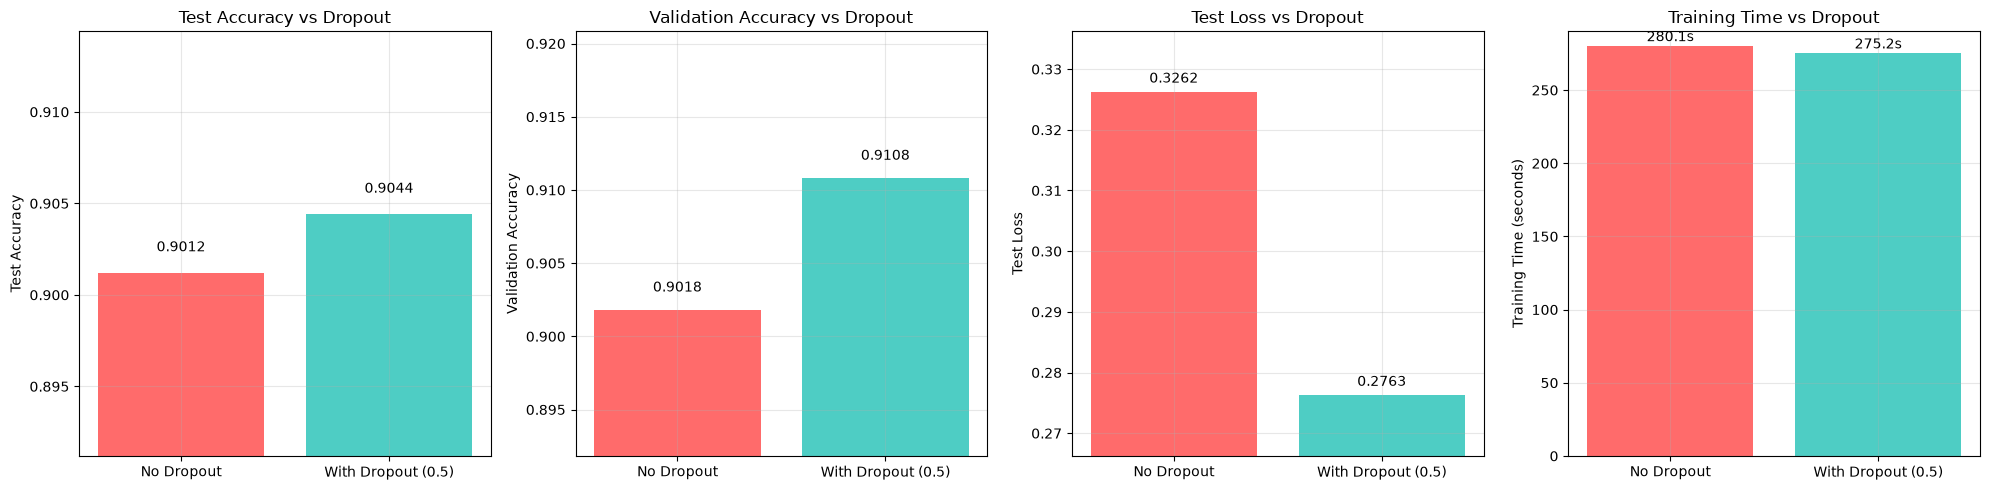

In [17]:
# dropout  
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

config_names = [r['config'] for r in results_dropout]

#Dropout vs Test Accuracy
ax = axes[0]
test_accs = [r['test_accuracy'] for r in results_dropout]
bars = ax.bar(config_names, test_accs, color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Test Accuracy vs Dropout')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(min(test_accs) - 0.01, max(test_accs) + 0.01)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom')

#Dropout vs Validation Accuracy
ax = axes[1]
val_accs = [r['val_accuracy'] for r in results_dropout]
bars = ax.bar(config_names, val_accs, color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Validation Accuracy vs Dropout')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(min(val_accs) - 0.01, max(val_accs) + 0.01)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom')

#Dropout vs Test Loss
ax = axes[2]
test_losses = [r['test_loss'] for r in results_dropout]
bars = ax.bar(config_names, test_losses, color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Test Loss vs Dropout')
ax.set_ylabel('Test Loss')
ax.set_ylim(min(test_losses) - 0.01, max(test_losses) + 0.01)
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, test_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom')

#Dropout vs Training Time
ax = axes[3]
training_times = [r['training_time'] for r in results_dropout]
bars = ax.bar(config_names, training_times, color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Training Time vs Dropout')
ax.set_ylabel('Training Time (seconds)')
ax.set_ylim(0, max(training_times) + 10)  # Start from 0 for time
ax.grid(True, alpha=0.3)
for bar, val in zip(bars, training_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

After testing all the models, we can see that increasing the number of filters from small (16,32) to medium (32,64) boosted test accuracy from 89.55% to 90.39%, and further increasing to large (64,128) only gave a tiny gain to 90.63%, while taking over three times longer to train (1244 seconds versus 361 seconds). This suggests that medium filters offer the best balance between learning capacity and efficiency, as they can detect more complex patterns than small filters, but large filters become redundant and unnecessarily slow down training.

Regarding regularization, the no-dropout model actually performed better (91.28%) than the version with a 0.5 dropout rate (90.57%). Both achieved the same validation accuracy (91.18%), but the dropout model took nearly twice as long to train. This indicates that for this relatively simple dataset (MNIST), the model was not severely overfitting, so adding dropout only increased training time without providing any real benefit. In fact, it slightly hurt test performance, likely because it forced the model to learn more robust features, but at the cost of losing some fine-grained detail that was actually useful.

Overall, the best choice depends on what we need: if we only care about high accuracy, choose No Dropout; if you want a safe and balanced model, choose the one with Dropout (0.5), because it is fast, stable, and still gives good results. 
As I want better accurancy then I think the best combination was the medium filter size (32 and 64) with no dropout, which achieved the highest test accuracy of 91.28% while keeping training time reasonable.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [18]:
# Build the final model: Medium filters (32,64) + No Dropout
final_model = Sequential()
final_model.add(Input(shape=(28, 28, 1)))
final_model.add(Conv2D(32, (3, 3), activation='relu'))
final_model.add(MaxPooling2D((2, 2)))
final_model.add(Conv2D(64, (3, 3), activation='relu'))
final_model.add(MaxPooling2D((2, 2)))
final_model.add(Flatten())
final_model.add(Dense(128, activation='relu'))
# No Dropout layer (best configuration from experiments)
final_model.add(Dense(10, activation='softmax'))

# Compile 
final_model.compile(optimizer=Adam(),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])


final_model.summary()

# Train the final model


start_time = time.time()
final_history = final_model.fit(X_train, y_train,
                                epochs=10,
                                batch_size=32,
                                validation_split=0.2)  

training_time = time.time() - start_time
# Evaluate on test set
test_loss, test_acc = final_model.evaluate(X_test, y_test)

# Report final performance

print(f"Configuration: Medium filters (32,64) + No Dropout")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Final Validation Accuracy (from training): {final_history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Accuracy: {final_history.history['accuracy'][-1]:.4f}")

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.8279 - loss: 0.4725 - val_accuracy: 0.8660 - val_loss: 0.3784
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8838 - loss: 0.3174 - val_accuracy: 0.8922 - val_loss: 0.2955
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9017 - loss: 0.2691 - val_accuracy: 0.8976 - val_loss: 0.2800
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9119 - loss: 0.2377 - val_accuracy: 0.9047 - val_loss: 0.2641
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9230 - loss: 0.2085 - val_accuracy: 0.9087 - val_loss: 0.2453
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9314 - loss: 0.1839 - val_accuracy: 0.9144 - val_loss: 0.2430
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9390 - loss: 0.1634 - val_accuracy: 0.9123 - val_loss: 0.2517
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9486 -

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final CNN model significantly outperforms the baseline. The baseline achieved a test accuracy of around 86.3%. In contrast, the final convolutional model reached a test accuracy of roughly 90.5%.
This improvement is mainly due to the CNN's architecture. By using convolutional layers, the model can effectively learn spatial features like edges and shapes directly , which is much more efficient for image recognition than the fully connected layers of the baseline.

The inclusion of convolutional and pooling layers allowed make the model more robust and the additional neurons (128 in the dense layer) gave it greater capacity to learn intricate patterns from the training data. The validation accuracy also shows that the model generalizes well.

If I had more time, I would try with other the optimizer, perhaps by testing different learning rates or trying the SGD optimizer with momentum, as this could help the model converge to a better minimum and potentially improve its accuracy on the test set.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.